# Imports

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Imports Loaders

In [10]:
import sys
import os
import subprocess
import importlib

sys.path.append(os.path.abspath(os.path.join('..')))

from engine.interop.loader import Loader
import engine.interop.linearModel as linear_model_module
importlib.reload(linear_model_module)
LinearModel = linear_model_module.LinearModel

# On doit restart kernel si on veut recharger la lib
try:
    Loader.loadLibrary(
        lib_name="libc",
        lib_folder="../libc",
        build_folder="../libc/build",
        specs_folder="../libc/specs",
        seed=None # ca va generer une seed aleatoire
    )

except Exception as e:
    if "already loaded" not in str(e).lower():
        raise RuntimeError(f"Failed to load library: {e}")
    
    print("Library already loaded, skipping.")

Library already loaded, skipping.


# Test Cases - LinearModel (lib C)

## Classification

### Donnees lineairement separables

In [11]:
np.random.seed(42)

X_clf = np.random.rand(1000, 2).astype(np.float32)
y_clf = (X_clf[:, 0] + X_clf[:, 1] - 0.7 >= 0).astype(np.float32)

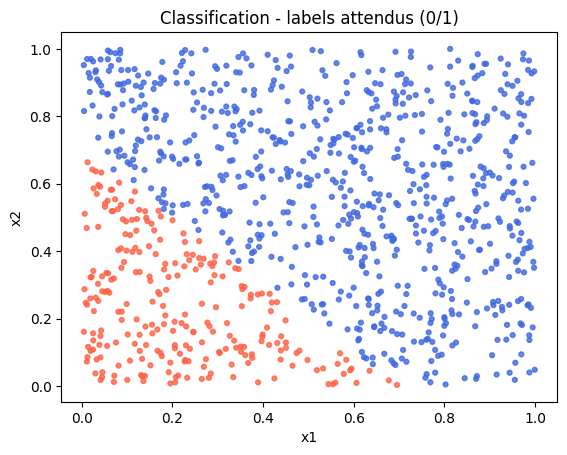

<Figure size 640x480 with 0 Axes>

In [12]:
colors = np.where(y_clf == 1.0, 'royalblue', 'tomato')
plt.scatter(X_clf[:, 0], X_clf[:, 1], c=colors, s=12, alpha=0.8)
plt.title('Classification - labels attendus (0/1)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()
plt.clf()

### Avant entrainement

In [13]:
model_clf = LinearModel.init_random(input_dim=2)

def classification_map(model, resolution=120):
    grid = np.array(
        [[x, y] for x in np.linspace(0.0, 1.0, resolution) for y in np.linspace(0.0, 1.0, resolution)],
        dtype=np.float32
    )
    pred = np.array([model.predict_linear_classification(p.tolist()) for p in grid], dtype=np.int32)
    return grid, pred

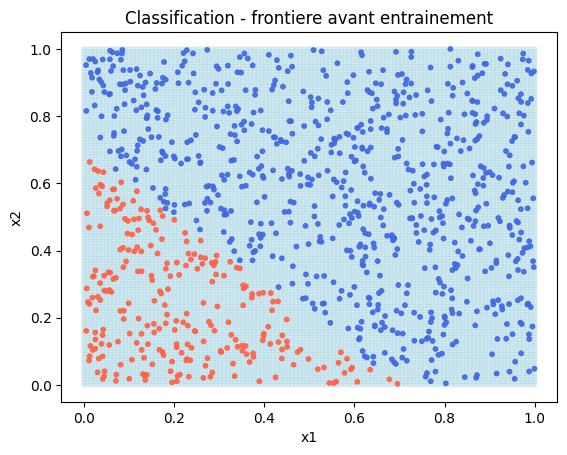

<Figure size 640x480 with 0 Axes>

In [14]:
grid_before, pred_before = classification_map(model_clf, resolution=120)
grid_colors_before = np.where(pred_before == 1, 'lightblue', 'mistyrose')

plt.scatter(grid_before[:, 0], grid_before[:, 1], c=grid_colors_before, s=8, alpha=0.35)
plt.scatter(X_clf[:, 0], X_clf[:, 1], c=colors, s=10, alpha=0.9)
plt.title('Classification - frontiere avant entrainement')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()
plt.clf()

### Entrainement

In [15]:
model_clf.train_linear_classification(
    dataset_inputs=X_clf.reshape(-1).astype(np.float32).tolist(),
    dataset_expected_outputs=y_clf.astype(np.float32).tolist(),
    alpha=0.05,
    epochs=80
)

pred_train = np.array([model_clf.predict_linear_classification(p.tolist()) for p in X_clf], dtype=np.int32)
acc = (pred_train == y_clf.astype(np.int32)).mean()
print(f"Accuracy entrainement (classification): {acc:.3f}")

Accuracy entrainement (classification): 1.000


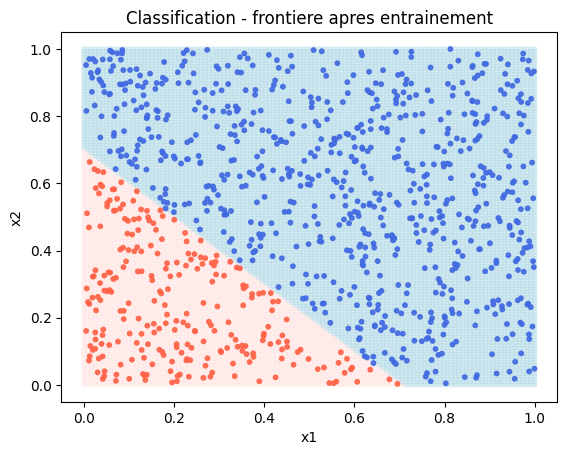

<Figure size 640x480 with 0 Axes>

In [16]:
grid_after, pred_after = classification_map(model_clf, resolution=120)
grid_colors_after = np.where(pred_after == 1, 'lightblue', 'mistyrose')

plt.scatter(grid_after[:, 0], grid_after[:, 1], c=grid_colors_after, s=8, alpha=0.35)
plt.scatter(X_clf[:, 0], X_clf[:, 1], c=colors, s=10, alpha=0.9)
plt.title('Classification - frontiere apres entrainement')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()
plt.clf()

## Regression lineaire

In [17]:
np.random.seed(7)

X_reg = np.linspace(-2.0, 2.0, 120, dtype=np.float32).reshape(-1, 1)
noise = np.random.normal(0.0, 0.2, size=(120,)).astype(np.float32)
y_reg = (1.8 * X_reg[:, 0] + 0.7 + noise).astype(np.float32)

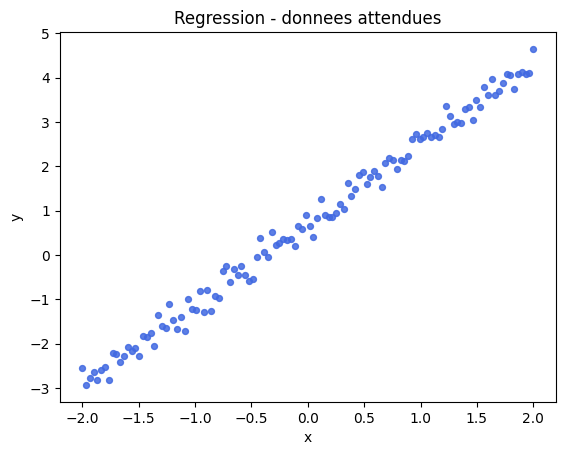

<Figure size 640x480 with 0 Axes>

In [18]:
plt.scatter(X_reg[:, 0], y_reg, s=18, alpha=0.85, color='royalblue')
plt.title('Regression - donnees attendues')
plt.xlabel('x')
plt.ylabel('y')
plt.show()
plt.clf()

### Avant entrainement

In [19]:
model_reg = LinearModel.init_random(input_dim=1)
y_pred_before = np.array([model_reg.predict_linear_regression([float(x)]) for x in X_reg[:, 0]], dtype=np.float32)

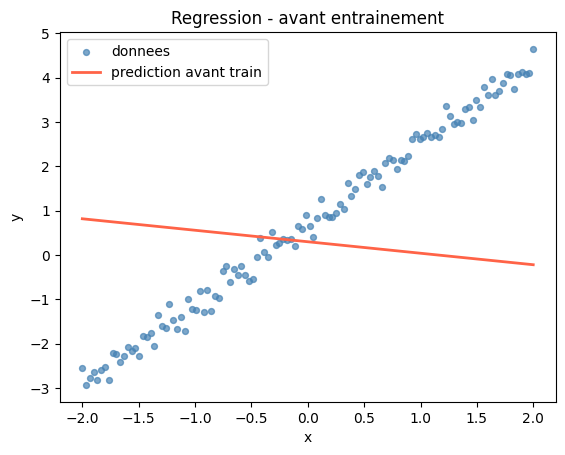

<Figure size 640x480 with 0 Axes>

In [20]:
plt.scatter(X_reg[:, 0], y_reg, s=18, alpha=0.7, color='steelblue', label='donnees')
plt.plot(X_reg[:, 0], y_pred_before, color='tomato', linewidth=2, label='prediction avant train')
plt.title('Regression - avant entrainement')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
plt.clf()

### Entrainement

In [21]:
model_reg.train_linear_regression(
    dataset_inputs=X_reg.reshape(-1).astype(np.float32).tolist(),
    dataset_expected_outputs=y_reg.astype(np.float32).tolist(),
    alpha=0.02,
    epochs=120
)

y_pred_after = np.array([model_reg.predict_linear_regression([float(x)]) for x in X_reg[:, 0]], dtype=np.float32)
mse = np.mean((y_reg - y_pred_after) ** 2)
print(f"MSE entrainement (regression): {mse:.4f}")

MSE entrainement (regression): 0.0394


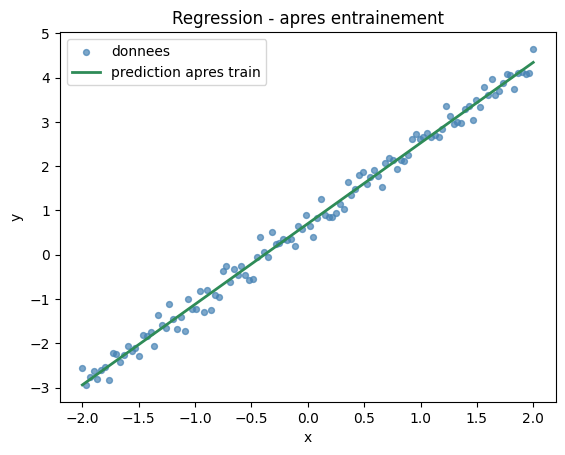

<Figure size 640x480 with 0 Axes>

In [22]:
plt.scatter(X_reg[:, 0], y_reg, s=18, alpha=0.7, color='steelblue', label='donnees')
plt.plot(X_reg[:, 0], y_pred_after, color='seagreen', linewidth=2, label='prediction apres train')
plt.title('Regression - apres entrainement')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
plt.clf()